In [1]:
import os
import torch
import numpy as np, pandas as pd, random
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt, seaborn as sns

import sklearn
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [2]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [3]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(seed=CFG['SEED'])

## Load Data

In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

ID = 'id'
TARGET = train.columns[-1]

CATS   = ['spectral_type', 'galaxy_population']
NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 12)
Test shape: (247435, 11)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig['g'], orig['r'])
orig['galaxy_population'] = galaxy_population(orig['u'], orig['r'])

orig.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 52.9+ MB


## Preprocess Features

In [7]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


1. seven photometric color differences: u-g, g-r, r-i, i-z, u-r, g-i, and r-z;
2. two redshift magnitude ratios: g/redshift and i/redshift;
3. magnitude mean/range plus log1p(redshift);
4. integer-floor categorical views of the numeric columns;
5. two delta quantile bins;
6. fold-safe multiclass target encoding for alpha_floor x delta_floor and u_floor x z_floor interaction categories.

In [8]:
## -- FE by @chris

X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
y = train[TARGET]
X_ts = test.drop(columns=[ID]); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_ts init shape:", X_ts.shape, "\n")

base_cat_cols = X.select_dtypes(include=['object']).columns.tolist()
base_num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Base categorical columns:', base_cat_cols)
print('Base numeric columns:', base_num_cols)

cat_cols = base_cat_cols.copy()
num_cols = base_num_cols.copy()

category_map = {}
# u-g, g-r, r-i, i-z, u-r, g-i, and r-z
color_pairs = [
    ('u', 'g'),
    ('g', 'r'),
    ('r', 'i'),
    ('i', 'z'),
    ('u', 'r'),
    ('g', 'i'),
    ('r', 'z'),
]
important_combos = [
    ('alpha_cat_', 'delta_cat_'),
    ('u_cat_', 'z_cat_'),
]

def feature_engineering(df, fit=False):
    df = df.copy()

    # Smooth numeric/color-locus features.
    df['_g_div_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    df['_i_div_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    for a, b in color_pairs:
        df[f'_{a}-{b}'] = (df[a] - df[b]).astype('float32')

    mags = df[['u', 'g', 'r', 'i', 'z']].astype('float32')
    df['_mag_mean'] = mags.mean(axis=1).astype('float32')
    df['_mag_range'] = (mags.max(axis=1) - mags.min(axis=1)).astype('float32')

    shifted_redshift = df['redshift'].astype('float32') - min(0.0, float(df['redshift'].min())) + 1e-4
    df['_log1p_redshift'] = np.log1p(shifted_redshift).astype('float32')

    # Original categorical columns.
    for col in base_cat_cols:
        if fit:
            codes, uniques = pd.factorize(df[col], sort=False)
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Integer-floor categorical views of every base numeric feature.
    for col in base_num_cols:
        cat_name = f'{col}_cat_'
        floored = np.floor(df[col]).astype('float32')
        if fit:
            codes, uniques = pd.factorize(floored, sort=False)
            category_map[cat_name] = uniques
        else:
            uniques = category_map[cat_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = floored.map(code_map).fillna(-1).astype('int32')
        df[cat_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Delta quantile bins from the best local run.
    for n_bins in [100, 500]:
        bin_name = f'delta_{n_bins}_quantile_bin_'
        if fit:
            kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', subsample=None)
            binned = kb.fit_transform(df[['delta']]).ravel().astype('int32')
            category_map[bin_name] = kb
        else:
            kb = category_map[bin_name]
            binned = kb.transform(df[['delta']]).ravel().astype('int32')
        df[bin_name] = pd.Series(binned, index=df.index).astype('int32').astype('category')

    # Interaction categories used only for fold-safe multiclass target encoding.
    combo_names = []
    for cols in important_combos:
        combo_name = '__'.join(cols) + '__'
        combo_names.append(combo_name)
        combo = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo = combo + '|' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    new_cat_cols = [c for c in df.columns if str(df[c].dtype) == 'category' and c not in base_cat_cols]
    new_num_cols = [c for c in df.columns if c.startswith('_') and str(df[c].dtype) != 'category']
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (577347, 10)
X_ts init shape: (247435, 10) 

Base categorical columns: ['spectral_type', 'galaxy_population']
Base numeric columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
len(new_cat_cols): 12
len(new_num_cols): 12 

prep len(cat_cols): 14
prep len(num_cols): 20 

X      prep shape: (577347, 34)
X_test prep shape: (247435, 34) 



In [9]:
# # -- FE by @yekenot

# X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
# y = train[TARGET]
# X_ts = test.drop(columns=[ID]); test_id = test[ID]

# del train, test
# print("X      init shape:", X.shape)
# print("X_ts init shape:", X_ts.shape, "\n")

# cat_cols = X.select_dtypes(include=['object']).columns.tolist()
# num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
# print("init len(cat_cols):", len(cat_cols))
# print("init len(num_cols):", len(num_cols), "\n")

# category_map = {}
# u-g, g-r, i-z, r-z, and u-z
# color_pairs = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
# ]
# important_combos = [
#     ('alpha_cat_', 'delta_cat_'),
#     ('u_cat_', 'z_cat_'),
# ]
# important_combos = sorted(important_combos)
# def feature_engineering(df, fit=False):
#     # Arithmetic interaction
#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_g_/_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
#     df['_i_/_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')
#     for a, b in color_pairs:
#         df[f"_{a}-{b}"] = (df[a] - df[b]).astype('float32')

#     # Categorize string cats
#     for col in cat_cols:
#         if fit:
#             codes, uniques = df[col].factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = df[col].map(code_map).fillna(-1).astype('int32')
#         df[col] = codes
#         df[col] = df[col].astype('category')

#     # Categorize numericals
#     for col in num_cols:
#         cat_name = f"{col}_cat_"
#         if fit:
#             codes, uniques = np.floor(df[col]).factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
#         df[cat_name] = codes
#         df[cat_name] = df[cat_name].astype('category')

#     # Discretize numericals
#     bin_config = {'delta': [100, 500]}
#     for col, bins_list in bin_config.items():
#         for n_bins in bins_list:
#             for strategy in ['quantile']:
#                 bin_name = f"{col}_{n_bins}_{strategy}_bin_"
#                 if fit:
#                     kb = KBinsDiscretizer(
#                         n_bins=n_bins,
#                         encode='ordinal',
#                         strategy=strategy,
#                         subsample=None
#                     )
#                     binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
#                     category_map[bin_name] = kb
#                 else:
#                     kb = category_map[bin_name]
#                     binned = kb.transform(df[[col]]).ravel().astype('int32')
#                 df[bin_name] = binned
#                 df[bin_name] = df[bin_name].astype('category')

#     # Create interaction categories
#     combo_names = []
#     for cols in important_combos:
#         combo_name = '_'.join(cols) + '_'
#         combo_names.append(combo_name)
#         combo_series = df[cols[0]].astype(str)
#         for col in cols[1:]:
#             combo_series = combo_series + '_' + df[col].astype(str)
#         if fit:
#             codes, uniques = pd.factorize(combo_series, sort=False)
#             category_map[combo_name] = uniques
#         else:
#             uniques = category_map[combo_name]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = combo_series.map(code_map).fillna(-1).astype('int32')
#         df[combo_name] = codes
#         df[combo_name] = df[combo_name].astype('category')

#     new_cat_cols = [col for col in df.columns if col.endswith('_')]
#     new_num_cols = [col for col in df.columns if col.startswith('_')]
#     return df, new_cat_cols, new_num_cols, combo_names

# X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
# X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
# cat_cols += new_cat_cols; num_cols += new_num_cols
# print("len(new_cat_cols):", len(new_cat_cols))
# print("len(new_num_cols):", len(new_num_cols), "\n")

# cat_cols = sorted(cat_cols)
# X = X.reindex(sorted(X.columns), axis=1)
# X_test = X_test.reindex(sorted(X_test.columns), axis=1)
# print("prep len(cat_cols):", len(cat_cols))
# print("prep len(num_cols):", len(num_cols), "\n")
# print("X      prep shape:", X.shape)
# print("X_test prep shape:", X_test.shape, "\n")

In [10]:
X.head()

,_g-i,_g-r,_g_div_redshift,_i-z,_i_div_redshift,_log1p_redshift,_mag_mean,_mag_range,_r-i,_r-z,_u-g,_u-r,alpha,alpha_cat_,alpha_cat___delta_cat___,delta,delta_100_quantile_bin_,delta_500_quantile_bin_,delta_cat_,g,g_cat_,galaxy_population,i,i_cat_,r,r_cat_,redshift,redshift_cat_,spectral_type,u,u_cat_,u_cat___z_cat___,z,z_cat_
0,2.638446,1.537632,53.536564,0.636056,47.085331,0.349989,21.120754,6.851065,1.100813,1.736869,3.576564,5.114196,147.734256,0,0,16.959273,43,215,0,21.895559,0,0,19.257113,0,20.357926,0,0.408982,0,0,25.472123,0,0,18.621057,0
1,1.860995,1.499854,120.821922,0.439634,109.041748,0.155332,18.293056,3.992077,0.361141,0.800775,1.691447,3.191300,127.988677,1,1,32.346716,66,331,1,19.087062,1,0,17.226067,1,17.587208,1,0.157976,0,0,20.778509,1,1,16.786433,1
2,0.496499,-0.092712,7.464886,0.025263,7.289058,1.343867,20.885235,0.614475,0.589211,0.614474,-0.043925,-0.136637,179.792648,2,2,35.344843,71,358,2,21.079128,0,1,20.582629,2,21.171840,2,2.823770,1,1,21.035203,2,2,20.557366,2
3,2.685077,2.032982,39.266460,0.450706,34.257919,0.435780,19.930828,5.390104,0.652096,1.102802,2.254320,4.287302,225.818295,3,3,48.569421,91,457,3,21.050736,0,0,18.365658,3,19.017754,3,0.536099,0,0,23.305056,3,3,17.914952,3
4,1.572233,1.237231,35.035980,0.283262,32.207016,0.448417,18.984982,4.086973,0.335002,0.618264,2.231478,3.468709,141.836135,4,4,19.342852,46,233,4,19.471680,1,0,17.899447,1,18.234449,4,0.555761,0,0,21.703158,2,4,17.616185,3


In [11]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [12]:
# X, X_ts, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     X,
#     X_ts,
#     X.iloc[:500],
#     features=NUMS+['Contract', 'InternetService', 'PaymentMethod'], # 
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

## Config

In [13]:
try:
    from tabpfn import TabPFNClassifier
except:
    %pip install -q -U tabpfn
    from tabpfn import TabPFNClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.9/273.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 

In [14]:
# !pip show tabpfn

In [15]:
from kaggle_secrets import UserSecretsClient

use_pfn_token = True

if use_pfn_token:
    ## Option 1: Use access token
    user_secrets = UserSecretsClient()
    secret_value_0 = user_secrets.get_secret("pfn_token")
    print('✓ Loaded successfully', secret_value_0)
    os.environ["TABPFN_TOKEN"] = secret_value_0
else:
    ## Option 2: Use direct model
    os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    print('✓ Loaded successfully')

✓ Loaded successfully tabpfn_sk_38W4jwH0z9vAW3C4Zj5Hbtcb7P4IgJLMgU3tpSQRGzg


In [16]:
combined = pd.concat([X, X_test])

for c in cat_cols:
    combined[c] = combined[c].astype(str)

X = combined[:len(X)]
X_test = combined[len(X):len(X)+len(X_test)]

## -- Get categorical indices --
cat_idx = [[*X.columns].index(f) for f in cat_cols]

tabpfn_model = TabPFNClassifier(**{
    'n_estimators': 8,
    'categorical_features_indices': cat_idx,
    'inference_config': {'SUBSAMPLE_SAMPLES': 20000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'fit_mode': 'fit_with_cache',
    'balance_probabilities': True,
    'tuning_config': {"tune_decision_thresholds": True},
    'eval_metric': 'balanced_accuracy',
    'random_state': CFG['SEED'],
    'device': ["cuda:0", "cuda:1"], # 'auto'
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
})

all_models = [
    ('tabpfn_mlp_c', tabpfn_model),
]
print('🤖 Model parameters defined!')

all_models

🤖 Model parameters defined!


[('tabpfn_mlp_c',
  TabPFNClassifier(balance_probabilities=True,
                   categorical_features_indices=[13, 14, 16, 17, 18, 20, 21, 23,
                                                 25, 27, 28, 30, 31, 33],
                   device=['cuda:0', 'cuda:1'], eval_metric='balanced_accuracy',
                   fit_mode='fit_with_cache', ignore_pretraining_limits=True,
                   inference_config={'SUBSAMPLE_SAMPLES': 20000}, random_state=42,
                   tuning_config={'tune_decision_thresholds': True}))]

In [17]:
# -- To use manual calibration --
# def Trainer_CV(model_name, base_model, X, y, X_ts, kf, cats, calibrator='iso'):
#     print(f"\n===== Starting Cross-Validation for {model_name} =====")
#     start = time()

#     num_classes = y.nunique()
#     class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}

#     oof_preds = np.zeros((len(X), num_classes))
#     test_preds = np.zeros((len(X_ts), num_classes))
#     fold_scores = []

#     calib_oof_preds = np.zeros((len(X), num_classes))
#     calib_test_preds = np.zeros((len(X_ts), num_classes))
#     calib_fold_scores = []

#     feat_importances = []

#     for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#         print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

#         ## -- Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = X_ts.copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # ## -- OPTION B: TE Merge original data --
#         # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
#         #     orig,
#         #     X_train,
#         #     X_valid,
#         #     X_test,
#         #     features=BASE,
#         #     target=TARGET,
#         #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#         #     # fill_nan=True,
#         # )

#         # CE_COLS = cats+ROUNDS
#         # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
#         # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
#         # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
#         # X_valid   = cm_enc.transform(X_valid).fillna(-1)
#         # X_test  = cm_enc.transform(X_test).fillna(-1)

#         # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
#         #     x_tr=X_train,
#         #     y_tr=y_train,
#         #     x_vl=X_valid,
#         #     x_ts=X_test,
#         #     bin_features=NUMS,
#         #     solver='cp', # 'cp', 'mip', 'lr'
#         #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#         #     pre_bins=100,
#         #     # period=300,
#         # )

#         # combined = pd.concat([X_train, X_valid, X_test])
#         # for c in cats:
#         #     combined[c] = combined[c].astype(str).astype('category')

#         # X_train = combined.iloc[:len(X_train)]
#         # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
#         # X_test  = combined.iloc[len(X_train)+len(X_valid):]

#         # ## -- Target Encoding --
#         # te_cols = ROUNDS
#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

#         ## -- Internal Split for Calibration --
#         X_base, X_calib, y_base, y_calib = train_test_split(
#             X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
#         )

#         print(f' • Training base model {X_base.shape}... ')
#         base_model.fit(X_base, y_base, X_valid, y_valid, cat_col_names=cats,
#                         # sample_weight=get_weights(y_base, y_train)
#         )

#         oof_preds[val_idx] = base_model.predict_proba(X_valid)
#         test_preds += base_model.predict_proba(X_test)

#         fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)

#         # lb = LabelBinarizer()
#         # y_val_one_hot = lb.fit_transform(y_valid)

#         ## ----------------------------------------------------
#         ## -- Calibrate for "true" probabilities --
#         if calibrator == 'sig':
#             print(f' • Calibrating model {X_calib.shape}... ', end='')
#             calib_model = CalibratedClassifierCV(FrozenEstimator(base_model),
#                                                  cv=None, method='sigmoid', n_jobs=-1)
#             calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

#             calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
#             calib_test_preds += calib_model.predict_proba(X_test)

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
#         elif calibrator == 'iso':
#             print(f' • Calibrating model {X_calib.shape}... ', end='')
#             calib_model = CalibratedClassifierCV(
#                 FrozenEstimator(base_model), cv=None, method='isotonic', n_jobs=-1
#             )
#             calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

#             calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
#             calib_test_preds += calib_model.predict_proba(X_test)

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
#         elif calibrator == 'venn_one':
#             print(f' • Training Venn-Abers 1-vs-1 {X_calib.shape}... ', end='')
#             vao = VennAbersCalibrator() ## Get OOF predictions --
#             oof_calib, oof_p0p1 = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                                     y_cal=y_calib.to_numpy(),
#                                                     p_test=base_model.predict_proba(X_valid),
#                                                     p0_p1_output=True, va_type='one_vs_one')
#             calib_oof_preds[val_idx] = oof_calib

#             vat = VennAbersCalibrator() ## Get TEST predictions --
#             test_calib, test_p0p1 = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                                       y_cal=y_calib.to_numpy(),
#                                                       p_test=base_model.predict_proba(X_test),
#                                                       p0_p1_output=True, va_type='one_vs_one')
#             calib_test_preds += test_calib

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(oof_calib.shape, test_calib.shape)
#         elif calibrator == 'venn_all':
#             print(f' • Training Venn-Abers 1-vs-all {X_calib.shape}... ', end='')

#             vao = VennAbersCalibrator() ## Get OOF predictions --
#             oof_calib, oof_p0p1 = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                                     y_cal=y_calib.to_numpy(),
#                                                     p_test=base_model.predict_proba(X_valid),
#                                                     p0_p1_output=True, va_type='one_vs_all')
#             calib_oof_preds[val_idx] = oof_calib

#             vat = VennAbersCalibrator() ## Get TEST predictions --
#             test_calib, test_p0p1 = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                                       y_cal=y_calib.to_numpy(),
#                                                       p_test=base_model.predict_proba(X_test),
#                                                       p0_p1_output=True, va_type='one_vs_all')
#             calib_test_preds += test_calib

#             calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#             calib_fold_scores.append(calib_fold_score)
#             print(oof_calib.shape, test_calib.shape)

#         get_base_loss  = log_loss(y_valid, oof_preds[val_idx])
#         get_calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

#         print(f"{CFG['YELLOW']} • FOLD {idx+1} RESULTS -------------------------")
#         print(f"bal_acc:  base -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
#         print(f'log_loss: base -> {get_base_loss:.5f} | calib -> {get_calib_loss:.5f}{CFG['RESET']}')
#         ## ----------------------------------------------------

#     ## -- Average test predictions --
#     test_preds /= kf.n_splits
#     calib_test_preds /= kf.n_splits

#     ## -- Print final cross-validation results --
#     print("\n=============================================")
#     print(f"Cross-Validation Results for {model_name}")
#     print("=============================================")
#     for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
#         print(f" • FOLD {i}: xgb -> {b:.5f} | calib -> {c:.5f}")

#     overall_score = np.round(balanced_acc(y, oof_preds), 5)
#     calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)

#     print(f"{'='*45}")
#     print(f"OOF: Base -> {overall_score} | Calib -> {calib_overall_score}")
#     print(f"{'-'*45}")
#     print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
#     print(f"{'-'*45}")
#     print(f"{CFG['GREEN']}Improved: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
#     print(f"{'='*45}")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'scores': [overall_score, calib_overall_score],
#         'models': base_model,
#         'oof_preds': [oof_preds, calib_oof_preds],
#         'test_preds': [test_preds, calib_test_preds],
#         'val_data': [X_valid, y_valid],
#     }

# print('⚙️⚙️ Training function ready ⚙️⚙️')

In [18]:
def Trainer_CV(model_name, base_model, X, y, X_ts, kf):
    print(f"\n===== Starting Cross-Validation for {model_name} =====")
    start = time()

    num_classes = y.nunique()
    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}

    oof_preds = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(X_ts), num_classes))
    fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # CE_COLS = cats+ROUNDS
        # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_valid   = cm_enc.transform(X_valid).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_valid,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100,
        #     # period=300,
        # )

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str).astype('category')

        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        ## -- Target Encoding --
        te_cols = combo_names
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        print(f' • Training model {X_train.shape}... ')
        base_model.fit(X_train, y_train)

        oof_preds[val_idx] = base_model.predict_proba(X_valid)
        test_preds += base_model.predict_proba(X_test)

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        fold_loss = log_loss(y_valid, oof_preds[val_idx])

        print(f"{CFG['YELLOW']}")
        print(f" • Fold {idx+1}: bal_acc -> {fold_score:.5f} | loss -> {fold_loss:.5f}")
        print(f"{CFG['RESET']}")
        ## ----------------------------------------------------

    ## -- Average test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n=============================================")
    print(f"Cross-Validation Results for {model_name}")
    print("=============================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i}: {score:.5f}")

    overall_score = np.round(balanced_acc(y, oof_preds), 5)

    print(f"{'='*45}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"{'='*45}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'scores': overall_score,
        'models': base_model,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'val_data': [X_valid, y_valid],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [19]:
all_model_predictions = {}

MULTI_SEEDS = SEED_2 = [CFG['SEED'], 777, 1234, 24611, 0]

CFG['FOLDS'] = 5
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [20]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [21]:
## -- Train models --
for (name, model) in all_models:
    all_model_predictions[name] = Trainer_CV(
        model_name=name,
        base_model=model,
        X=X,
        y=y, #[:10_000]
        X_ts=X_test,
        kf=kf,
    )


===== Starting Cross-Validation for tabpfn_mlp_c =====

***** FOLD 1/5 *****
 • Target Encoding 2 features... 
 • Training model (461877, 38)... 


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]


 • Fold 1: bal_acc -> 0.96528 | loss -> 0.10808


***** FOLD 2/5 *****
 • Target Encoding 2 features... 
 • Training model (461877, 38)... 

 • Fold 2: bal_acc -> 0.96511 | loss -> 0.10683


***** FOLD 3/5 *****
 • Target Encoding 2 features... 
 • Training model (461878, 38)... 

 • Fold 3: bal_acc -> 0.96438 | loss -> 0.11106


***** FOLD 4/5 *****
 • Target Encoding 2 features... 
 • Training model (461878, 38)... 

 • Fold 4: bal_acc -> 0.96419 | loss -> 0.10936


***** FOLD 5/5 *****
 • Target Encoding 2 features... 
 • Training model (461878, 38)... 

 • Fold 5: bal_acc -> 0.96466 | loss -> 0.11010


Cross-Validation Results for tabpfn_mlp_c
 • Fold 1: 0.96528
 • Fold 2: 0.96511
 • Fold 3: 0.96438
 • Fold 4: 0.96419
 • Fold 5: 0.96466
OOF Score: 0.96473
AVG Score: 0.96473 ± 0.00041
27.42 mins



In [22]:
# =============================================
# Results for @yekenot tabpfn_mlp_
# =============================================
#  • Fold 1: 0.96467
#  • Fold 2: 0.96514
#  • Fold 3: 0.96380
#  • Fold 4: 0.96384
#  • Fold 5: 0.96390
# =============================================
# OOF Score: 0.96427
# ---------------------------------------------
# AVG Score: 0.96427 ± 0.00054
# =============================================
# 7.44 mins

# =============================================
# Results for @chris tabpfn_mlp_
# =============================================
#  • Fold 1: 0.96408
#  • Fold 2: 0.96490
#  • Fold 3: 0.96256
#  • Fold 4: 0.96343
#  • Fold 5: 0.96385
# =============================================
# OOF Score: 0.96376
# AVG Score: 0.96376 ± 0.00077
# =============================================
# 7.83 mins

## Evaluation and Submission

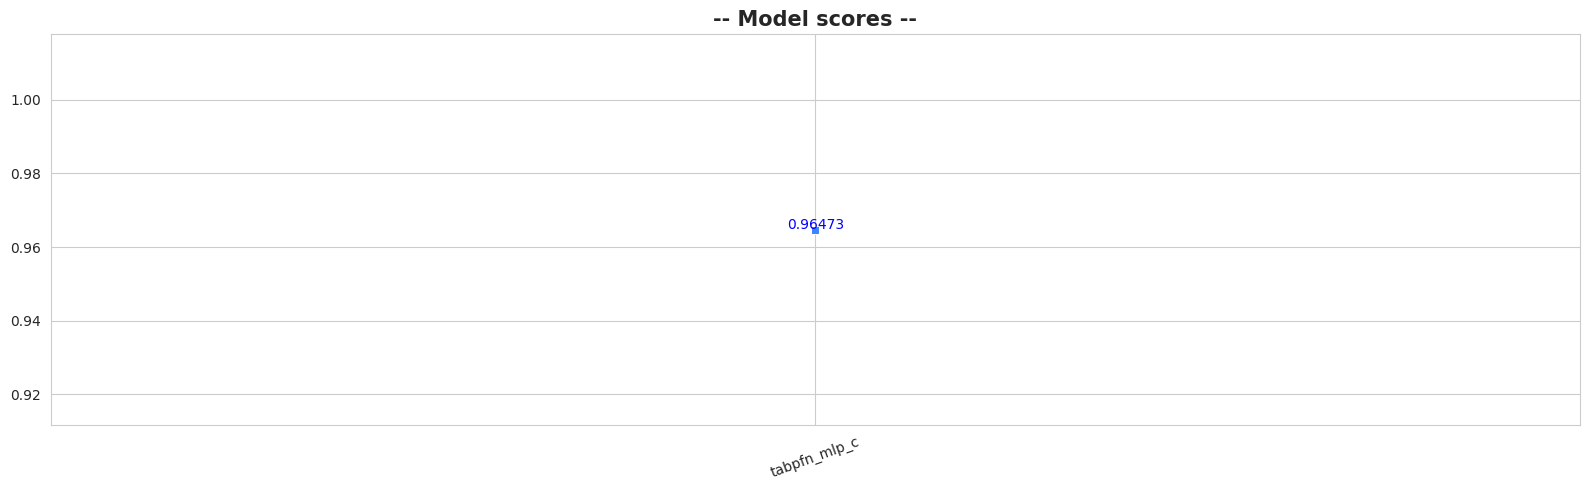

In [23]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, z in v.items():
        if x == 'scores':
            all_model_scores[k] = z

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group)
    names.append(k)

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot(raw_scores, marker='s')

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+1e-4, s1, ha='center', va='baseline', color='b')

# plt.ylim((0.97, 0.99))
# plt.legend(loc='best')
plt.xticks(range(len(names)), names, rotation=20)
plt.title('-- Model scores --', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout()
plt.show()

In [24]:
## -- Get OOF predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, z in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_pytab_{n}.npy", z)
            print(f'{n} oof saved!')

            # ## -- Create calib submission file --
            # cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            # np.save(f"oof_calib_{cal_n}_.npy", z[1])
            # print(f'OOF file for calibrated model saved!')

            print()

tabpfn_mlp_c_96473 oof saved!



Submission tabpfn_mlp_c_96473 saved! (247435,)


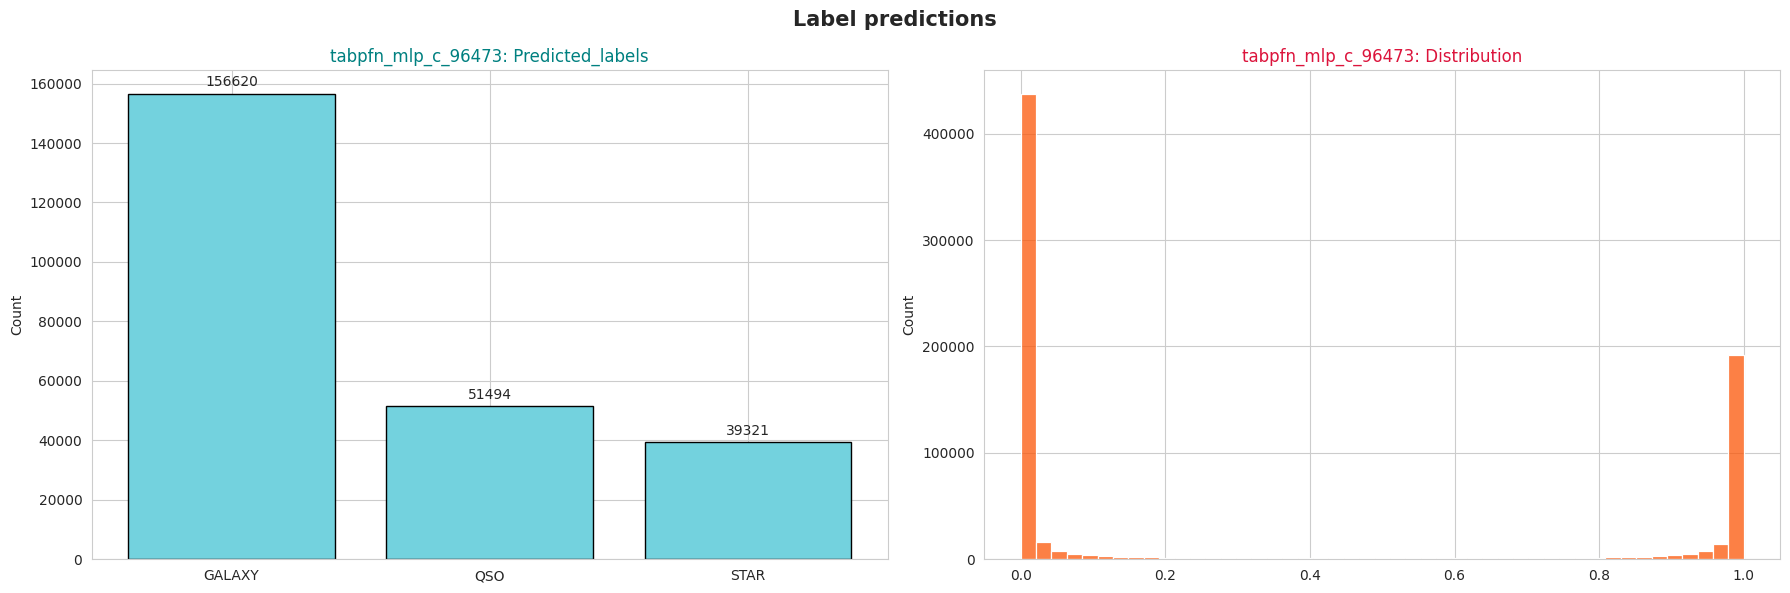

In [25]:
## -- Get TEST predictions/submissions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, z) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_pytab_{n}.npy", z)
            
            base_preds = np.argmax(z, axis=1)
            submit[TARGET] = pd.Series(base_preds).map(r_mapping)
            submit.to_csv(f'submit_pytab_{n}.csv', index=False)
            print(f'Submission {n} saved! {base_preds.shape}')

            # ## -- Calib submission file --
            # cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            # np.save(f"test_calib_{cal_n}_.npy", y[1])
            
            # calib_preds = np.argmax(y[1], axis=1)
            # submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
            # submit.to_csv(f'submit_calib_{cal_n}_.csv', index=False)
            # print(f'Submission calib TEST file saved! {calib_preds.shape}')

            counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

            fig, axs = plt.subplots(1, 2, figsize=(18, 6))
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(z.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [26]:
# !rm -r /kaggle/working